# example.py
Example script describing how to use the SysID library. 

Here, we aim to approximate the function: 
$F(t) = 0.732 + sin(t) + 0.64 \cdot (cos(\pi \cdot t))^{(2)} + 0.32 \cdot cos(\pi \cdot t) \cdot sin(t) - 0.25 \cdot (sin(t))^{(2)} + \textrm{White Noise}$

This particular function is chosen as we can use it to verify the functionality of the stepwise regression algorithm. As we will show later, this function can be interpretted as a polynomial model. 

First we import all of our dependencies
# Imports

In [1]:
import SysID
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt 
from Utility import Utility
import os

# Definitions
We define a function that adds white noise to a signal

In [2]:
def addWhiteNoise(x, seed, mu = 0, sigma = 0.05):
    # Set seed in isolated variable
    rng = np.random.RandomState(seed)
    # create white noise signal
    white_noise = rng.normal(mu, sigma, x.shape)
    return x + white_noise

And another function which gives us our analytical solution of the equation we are trying to model.
$F(t) = 0.732 + sin(t) + 0.64 \cdot (cos(\pi \cdot t))^{(2)} + 0.32 \cdot cos(\pi \cdot t) \cdot sin(t) - 0.25 \cdot (sin(t))^{(2)} + \textrm{White Noise}$

In [3]:
def getF(t):
    F = 0.732 + np.sin(t) + 0.64*(np.cos(np.pi*t))**(2) + 0.32*np.cos(np.pi*t)*np.sin(t) - 0.25 * (np.sin(t))**(2)
    return F

# Initialization
Let us now build our data set

## Defining time vector
First, we define a time vector, upon which our data set is built. Feel free to modify the starting time (`tStart`), ending time (`tEnd`), and time step (`dt`). 

In [4]:
tStart = 0
tEnd = 20
dt = 0.005
t = np.arange(tStart, tEnd, dt)

## Defining data set
We note that the target function is actually a polynomial model of the variables: 
- $x_{1} = sin(t)$
- $x_{2} = cos(\pi \cdot t)$

We may also define our target variables (i.e. $F(t)$)

In [5]:
x1_clean = np.sin(t)
x2_clean = np.cos(np.pi*t)
F_clean = getF(t)

Running the identification routine with the data as-is will give an exact solution, and is unrepresentative of reality. As such, we can add white noise to these data, initialized with a different seed each such that there is no correlation between the noise of these data. 

In [6]:
x1 = addWhiteNoise(x1_clean, 1111)
x2 = addWhiteNoise(x2_clean, 2222)
F_noisy = addWhiteNoise(F_clean, 3333)

# Model identification

## Data preparation
The `SysID.Model` class works with pandas DataFrames to identify models. As such, we need to construct a DataFrame of our predictors: $x_{1}$ and $x_{2}$. 

As predictions are accompanied by their prediction intervals, we also define a confidence level. 

In [7]:
# Preparing data
Data = pd.DataFrame(np.vstack((x1, x2)).T, columns=['x1', 'x2'])

# Confidence level for prediction intervals 
predictionIntervalConfidenceLevel = 0.95

## Polynomial model
The stepwise regression algorithm works by sequentially selecting the most appropriate regressors to fit a model from a candidate pool of regressors. 

## Model compilation
**Defining candidate regressors**

As the candidate pool of regressors can be quite large and tedious to input manually, there is a specific syntax used by the `SysID.Model` to streamline the definition of candidate regressors. 

Candidate regressors are derived from a candidate polynomial. To define this polynomial, the base variables, degree, and so-called 'sets' need to be defined in a dictionary with keys:
- "vars" - describes the base predictors, as a list
- "degree" - integer of the polynomial degree
- "sets" - a list of constants/variables to multiply the entire polynomial by, if only the base polynomial is requred, then $[1]$ should be passed


Example:
Using the variables, $x_{1}$ and $x_{2}$, from above, let us say that we would want to construct a polynomial (structure) given by:

$P(x_{1}, x_{2}) = x_{1} + x_{2} + x_{1}\cdot x_{2} + x_{1}^{2} + x_{2}^{2}$

*Note that the regressor coefficients are ignored here since we only care about the regressor structures at this stage. The final coefficient will be determined when training the model, such that it best-fits the data. So any coefficients defined at this stage will be absorbed by the final coefficient.*

*Furthermore, the bias vector is not shown here since it is included by default when identifying polynomial models*

Here, our 'base' variables are $x_{1}$ and $x_{2}$ and our polynomial degree is $2$. In this example, sets = $[1]$ since we only have the 'base' polynomial. So our candidate polynomial dictionary is given by:

```
{
'vars':['x1', 'x2'],
'degree':2, 
'sets':[1]
}
```

Let us say that we have an additional variable, given by $x_{3} = tan(t)$, which we suspect to only affect the data in a linear fashion (either by itself or as an interaction with $x_{1}$ or $x_{2}$). We can incorporate this effect into our candidate pool through the 'sets' field, namely:

```
{
'vars':['x1', 'x2'],
'degree':2, 
'sets':[1, 'x3']
}
```

Will produce the following polynomial:

$P(x_{1}, x_{2}) = 1 \cdot \left ( x_{1} + x_{2} + x_{1}\cdot x_{2} + x_{1}^{2} + x_{2}^{2} \right ) + x_{3} \cdot \left ( x_{1} + x_{2} + x_{1}\cdot x_{2} + x_{1}^{2} + x_{2}^{2} \right )$


Moreover, several candidate polynomials may be combined in a list to form the complete candidate pool of regressors. Continuing with the previous example of $x_{3}$, if we instead suspect it to influence our targets cubically but **independently** of $x_{1}$ or $x_{2}$ we can specify:
```
[
{
'vars':['x1', 'x2'],
'degree':2, 
'sets':[1]
},
{
'vars':['x3'],
'degree':2, 
'sets':[1]
}
]
```
To produce a list of candidate polynomial structures. 

In fact **we must always pass a list of candidate structures**, even if we only have one candidate polynomial. 

This is the case for our running example, and thus we define the following candidate polynomial structure. 

In [8]:
# Define candidate model structure
polyCandidates = [
    {'vars':['x1', 'x2'],
     'degree':3,
     'sets':[1]}
]

**Defining fixed regressors**

There are also occasions where we know exactly how certain variables influence the targets. For such variables, we can specify a list of 'fixed regressors' which may be themselves an algebraic equation of the base variables (e.g. $x_{1}$, $x_{2}$). 

Say, for example, that we know that our targets are modulated (linearly) by the following equations:
- $(x_{1} - x_{2})^{(2)}$
- $(x_{1}/x_{2})^{(x_{1} + 10)}$

We can specify these as fixed regressors through string equations, for example:
```
fixedRegressors = ["(x1 - x2)^(2)", "(x1/x2)^(x1 + 10)"]
```

However, there are also cases where there are no such regressors, so we may instead pass an empty list such as:
```
fixedRegressors = []
```

This is indeed the case for our current running example, so:

In [9]:
fixedRegressors = []

We now have all the necessary inputs required to compile our model. So we can compile our polynomial model as follows: 

*Note that, as most models include a bias vector (i.e. constant in polynomial model), this is enabled by default. However, to make this bias inclusion explicit, we specify includeBias = True. If for any reason a bias vector is not required, then it may be set to False. In this case, though, a fixed regressor must be passed since the algorithm requires a starting (i.e. reference) model. It is therefore not recommended to set includeBias = False*

In [10]:
# Initialize model
PolyModel = SysID.Model('stepwise_regression')

# Compile model
PolyModel.compile(Data, polyCandidates, fixedRegressors, includeBias = True)

### Training polynomial model & making predictions

After model compilation, we can train the polynomial model on the training data and make predictions from the resultant model. 

To visualize the model performance, we can plot it alongside the noisy and clean targets. As the `SysID.Model` class provides information on the model prediction reliability, we may also plot the associated prediction intervals (up to confidence level set by: `predictionIntervalConfidenceLevel` above)


[-------------------------------------------------]
[ INFO ] Initial values
[ INFO ] Selected regressor: None
[ INFO ] Removed regressor: None
[ INFO ] Predict square error: 0.5649796914730747
[ INFO ] Coefficient of Determination (R2): 8.054191964427191e-16

[-------------------------------------------------]
[ INFO ] Current step: 1
[ INFO ] Selected regressor: (x1^(1.0))
[ INFO ] Removed regressor: None
[ INFO ] Predict square error: 0.0744146289840895
[ INFO ] Coefficient of Determination (R2): 0.8695128314396874

[-------------------------------------------------]
[ INFO ] Current step: 2
[ INFO ] Selected regressor: (x2^(2.0))
[ INFO ] Removed regressor: None
[ INFO ] Predict square error: 0.027259860940017453
[ INFO ] Coefficient of Determination (R2): 0.953685930058334

[-------------------------------------------------]
[ INFO ] Current step: 3
[ INFO ] Selected regressor: (x1^(1.0) * x2^(1.0))
[ INFO ] Removed regressor: None
[ INFO ] Predict square error: 0.0143854902224593

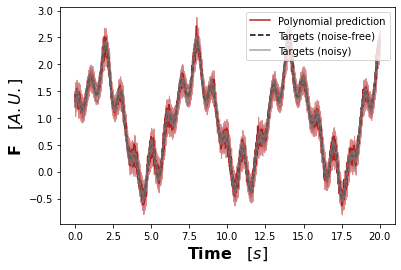

In [11]:
# Train model
PolyModel.train(Data, F_noisy, stop_criteria = 'PSE')
# Make predictions
polyPred, polyPredVar = PolyModel.predict(Data)
# Get polynomial (95%) prediction interval bounds
PolyPI_lower, PolyPI_upper = Utility.buildIntervalBounds(predictionIntervalConfidenceLevel, polyPred, polyPredVar)

# Plot results
fig = plt.figure()
ax = fig.add_subplot(111)
ax.fill_between(t, np.array(PolyPI_lower).reshape(-1), np.array(PolyPI_upper).reshape(-1), color = 'firebrick', alpha = 0.5)
ax.plot(t, polyPred, label = 'Polynomial prediction', color='firebrick')
ax.plot(t, F_clean, label='Targets (noise-free)', linestyle = '--', color = 'k')
ax.plot(t, F_noisy, label='Targets (noisy)', linestyle = '-', color = 'grey', alpha = 0.7)
ax.set_xlabel(r'$\mathbf{Time} \quad [s]$', fontsize = 16)
ax.set_ylabel(r'$\mathbf{F} \quad [A.U.]$', fontsize = 16)
ax.legend()
plt.show()

### Summarizing model

At any point following model initialization, we may check the summary and state of the model through the `SysID.Model.summary()` method as shown below. 


In [12]:
# Print identified model; we see that the selected regressors match the analytical solution with similar coefficients to the expected solution. 
PolyModel.summary()



#################################################################
                          Model Summary                          
#################################################################
Technique:                                    stepwise_regression
Model State:                                              Trained
_________________________________________________________________
------------------------Chosen Regressors------------------------
Regressor                                                   Value
-----------------------------------------------------------------
bias                                                   7.379e-01
(x1^(1.0))                                             9.940e-01
(x2^(2.0))                                             6.077e-01
(x1^(1.0)*x2^(1.0))                                    3.088e-01
(x1^(2.0))                                             -2.314e-01
_________________________________________________________________
Total number

Recall that the function we are trying to approximate is:

$F(t) = 0.732 + sin(t) + 0.64 \cdot (cos(\pi \cdot t))^{(2)} + 0.32 \cdot cos(\pi \cdot t) \cdot sin(t) - 0.25 \cdot (sin(t))^{(2)} + \textrm{White Noise}$

Where:
- $x_{1} = sin(t)$
- $x_{2} = cos(\pi \cdot t)$

Therefore, the most appropriate polynomial approximation of $F(t)$ is clearly:

$\hat{F}(t) = 0.732 + x_{1} + 0.64 \cdot x_{2}^{(2)} + 0.32 \cdot x_{2} \cdot x_{1} - 0.25 \cdot x_{2}^{(2)}$

Through the printed summary, we can see that the correct polynomial structure is indeed identified with (approximately) accurate coefficients. 

### Saving models

We can also save our models by providing a save directory, as shown below. Here, we save the models to the exampleData/exampleModel sub directory.

In [13]:
# Save polynomial model 
savePath = os.path.join(os.getcwd(), 'exampleData', 'examplePolyModel')
PolyModel.save(savePath)

## Neural Network model

### Initialization and compilation

As with the polynomial model, we first need to intialize and compile our model. 

In this example, we will use a simple feed-forward (dense) neural network architecture with 
- 1 hidden layer
- 10 hidden neurons
- 'relu' hidden activation function

To mitigate over-fitting, we will train an ensemble of 10 individual neural networks with the aforementioned structure. 

In [14]:
# Initialize model
NeuralNetModel = SysID.Model('ANN')
# Compile (single layer) ANN model. modelOutput = Point means that the prediction intervals (PIs) will be estimated through the bootstrap method (i.e. external ANN estimates PIs.)
NeuralNetModel.compile(Data, F_noisy, num_ensembles = 10, ANN_type = 'FNN', num_hidden_layers = 1, num_hidden_neurons = 10, hidden_activation = 'relu', modelOutput = 'point')

[ INFO ] Compiling <10> model ensembles of type <FNN> with output method <point>


### Training Neural network model & making predictions 

As the neural network module of the `SysID.Model` class uses the `tensorflow` library to handle the bulk of the neural network modelling, all of the standard configurable training parameters may be passed through the `SysID.Model.train` method for neural networks as well. 

It is recommended that the `applyNormalization` feature is used during training to improve the peformance of the neural network models. 

Moreover, the standard `tensorflow` library does not (yet) associate prediction intervals with the model predictions. The `SysID.Model` can approximate these prediction intervals instead, but users must request this through `bootstrapPIs=True` as shown below. 

[------------------------------]
[ INFO ] Splitting training data into training subsets...
[------------------------------]
[ INFO ] Training model [1/10]
Epoch 1/10
80/80 [==============================] - 0s 623us/step - loss: 0.0327 - mae: 0.1444
Epoch 2/10
80/80 [==============================] - 0s 554us/step - loss: 0.0271 - mae: 0.1317
Epoch 3/10
80/80 [==============================] - 0s 509us/step - loss: 0.0237 - mae: 0.1234
Epoch 4/10
80/80 [==============================] - 0s 542us/step - loss: 0.0215 - mae: 0.1177
Epoch 5/10
80/80 [==============================] - 0s 545us/step - loss: 0.0201 - mae: 0.1138
Epoch 6/10
80/80 [==============================] - 0s 589us/step - loss: 0.0191 - mae: 0.1110
Epoch 7/10
80/80 [==============================] - 0s 503us/step - loss: 0.0185 - mae: 0.1090
Epoch 8/10
80/80 [==============================] - 0s 541us/step - loss: 0.0180 - mae: 0.1076
Epoch 9/10
80/80 [==============================] - 0s 532us/step - loss: 0.0176 - ma

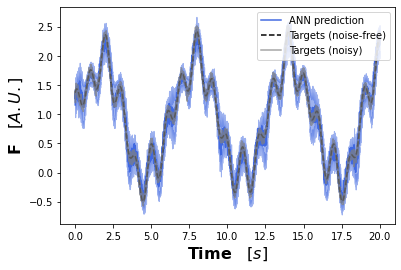

In [17]:
# Train ANN model
NeuralNetModel.train(Data, F_noisy, applyNormalization = True, epochs = 10, verbose = 1, bootstrapPIs = True, bootstrapPI_kwargs={'verbose':0})
# Make predictions
NeuralNetPred, NeuralNetPredVar = NeuralNetModel.predict(Data)
# Get polynomial (95%) prediction interval bounds
NeuralNetPI_lower, NeuralNetPI_upper = Utility.buildIntervalBounds(predictionIntervalConfidenceLevel, NeuralNetPred, NeuralNetPredVar)
# Plot results
fig = plt.figure()
ax = fig.add_subplot(111)
ax.fill_between(t, np.array(NeuralNetPI_lower).reshape(-1), np.array(NeuralNetPI_upper).reshape(-1), color = 'royalblue', alpha = 0.5)
ax.plot(t, NeuralNetPred, label = 'ANN prediction', color='royalblue')
ax.plot(t, F_clean, label='Targets (noise-free)', linestyle = '--', color = 'k')
ax.plot(t, F_noisy, label='Targets (noisy)', linestyle = '-', color = 'grey', alpha = 0.7)
ax.set_xlabel(r'$\mathbf{Time} \quad [s]$', fontsize = 16)
ax.set_ylabel(r'$\mathbf{F} \quad [A.U.]$', fontsize = 16)
ax.legend()
plt.show()


# Model comparison 

The performance of the two models can be compared by looking at their accuracy with respect to the target data (RMSE) and the quality of their prediction intervals (PICP & MPIW). 

- PICP = Proportion of data contained within estimated prediction intervals. Models are considered valid for PICP >= predictionIntervalConfidenceLevel (so PICP >= 95% if confidence level of 0.95 is chosen)
- MPIW = Mean width of the prediction intervals. The lower the MPIW, the better (narrow PIs), assuming valid PICP
- RMSE = Root mean squared error. The lower the RMSE, the closer the prediction resembles the training targets (but there may be over-fitting). 

[ INFO ] Performance comparison
	 Polynomial model:
		PICP =     94.90
		MPIW =     10.95
		RMSE =     8.66841e-02
	 Neural network model:
		PICP =     98.15
		MPIW =     19.04
		RMSE =     1.29691e-01


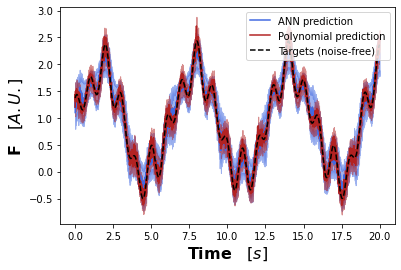

In [16]:
# Compare PI and fit performance
PolyPICP, PolyMPIW = Utility.qualityPI(F_noisy, np.array(polyPred).reshape(-1), np.array(polyPredVar).reshape(-1), conf=predictionIntervalConfidenceLevel)
PolyRMSE = PolyModel._RMSE(F_noisy, polyPred)
NeuralNetPICP, NeuralNetMPIW = Utility.qualityPI(F_noisy, np.array(NeuralNetPred).reshape(-1), np.array(NeuralNetPredVar).reshape(-1), conf=predictionIntervalConfidenceLevel)
NeuralNetRMSE = NeuralNetModel._RMSE(F_noisy, NeuralNetPred)

print('[ INFO ] Performance comparison')
print('\t Polynomial model:')
print('\t\t{:<10} {:.2f}'.format('PICP =', PolyPICP))
print('\t\t{:<10} {:.2f}'.format('MPIW =', PolyMPIW))
print('\t\t{:<10} {:.5e}'.format('RMSE =', PolyRMSE))
print('\t Neural network model:')
print('\t\t{:<10} {:.2f}'.format('PICP =', NeuralNetPICP))
print('\t\t{:<10} {:.2f}'.format('MPIW =', NeuralNetMPIW))
print('\t\t{:<10} {:.5e}'.format('RMSE =', NeuralNetRMSE))

fig = plt.figure()
ax = fig.add_subplot(111)
ax.fill_between(t, np.array(NeuralNetPI_lower).reshape(-1), np.array(NeuralNetPI_upper).reshape(-1), color = 'royalblue', alpha = 0.5)
ax.plot(t, NeuralNetPred, label = 'ANN prediction', color='royalblue')
ax.fill_between(t, np.array(PolyPI_lower).reshape(-1), np.array(PolyPI_upper).reshape(-1), color = 'firebrick', alpha = 0.5)
ax.plot(t, polyPred, label = 'Polynomial prediction', color='firebrick')
ax.plot(t, F_clean, label='Targets (noise-free)', linestyle = '--', color = 'k')
# ax.plot(t, F_noisy, label='Targets (noisy)', linestyle = '-', color = 'grey', alpha = 0.5)
ax.set_xlabel(r'$\mathbf{Time} \quad [s]$', fontsize = 16)
ax.set_ylabel(r'$\mathbf{F} \quad [A.U.]$', fontsize = 16)
ax.legend()
plt.show()

From these results, it is evident that the polynomial model produces the better fit (at the risk of over-fitting the target data). 

Indeed some over-fitting of the polynomial may be occuring given that the PICP is slightly below the requirement of 95%. 

In comparison, the neural network model shows a satisfactory PICP, at the cost of almost double the width PIs. Despite the widened PIs, the neural network model affords a lower RMSE than the polynomial model. 